Notebook to easly check the bounding box generated with yolo for a fast visual assesment

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from ast import literal_eval
import random

# Configuration
DATA_DIR = r"C:\Users\Stefano\Documents\Uni\UniLu\CVIA\data"

SPLIT = "train"
CSV_PATH = "../BoundingBoxes/detection_"+SPLIT+".csv" # Path to your generated CSV
# Load results
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} predictions.")

Loaded 60000 predictions.


In [4]:
def visualize_prediction(row_idx):
    row = df.iloc[row_idx]
    filename = row['filename']
    class_name = row['class']
    bbox = literal_eval(row['bbox']) # Convert string "(x1, y1, x2, y2)" to tuple
    
    # Path structure: data/images/split/class/img
    img_path = os.path.join(DATA_DIR, "images", class_name, SPLIT,filename)
    
    if not os.path.exists(img_path):
        print(f"Error: Image not found at {img_path}")
        return

    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    # Bbox: (x_min, y_min, x_max, y_max)
    x_min, y_min, x_max, y_max = bbox
    width = x_max - x_min
    height = y_max - y_min

    # Create rectangle patch
    rect = mpatches.Rectangle(
        (x_min, y_min), width, height, 
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)

    plt.title(f"File: {filename} | Class: {class_name}")
    plt.axis('off')
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
from ast import literal_eval

def plot_crop(row, input_root, split="train", padding=0):
    """
    Plots a crop of the image based on the bounding box using matplotlib.
    """
    filename = row['filename']
    class_name = row['class']
    bbox = literal_eval(row['bbox']) # Parse "(x_min, y_min, x_max, y_max)"
    
    # Path: data/images/split/class/img
    img_path = os.path.join(input_root, "images", split, class_name, filename)
    
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")
        return

    # Load original image
    img = Image.open(img_path)
    W, H = img.size
    x_min, y_min, x_max, y_max = bbox

    # Apply padding and clamp to image boundaries
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(W, x_max + padding)
    y_max = min(H, y_max + padding)

    # Perform crop
    crop = img.crop((x_min, y_min, x_max, y_max))

    # Visualization with Matplotlib
    plt.figure(figsize=(6, 6))
    plt.imshow(crop)
    plt.title(f"Crop: {class_name}\n{filename}", fontsize=10)
    plt.axis('off') # Hide axes for a cleaner look
    plt.show()

# --- Example of usage ---
# row = df.iloc[0]
# plot_crop(row, DATA_DIR, split=SPLIT, padding=15)

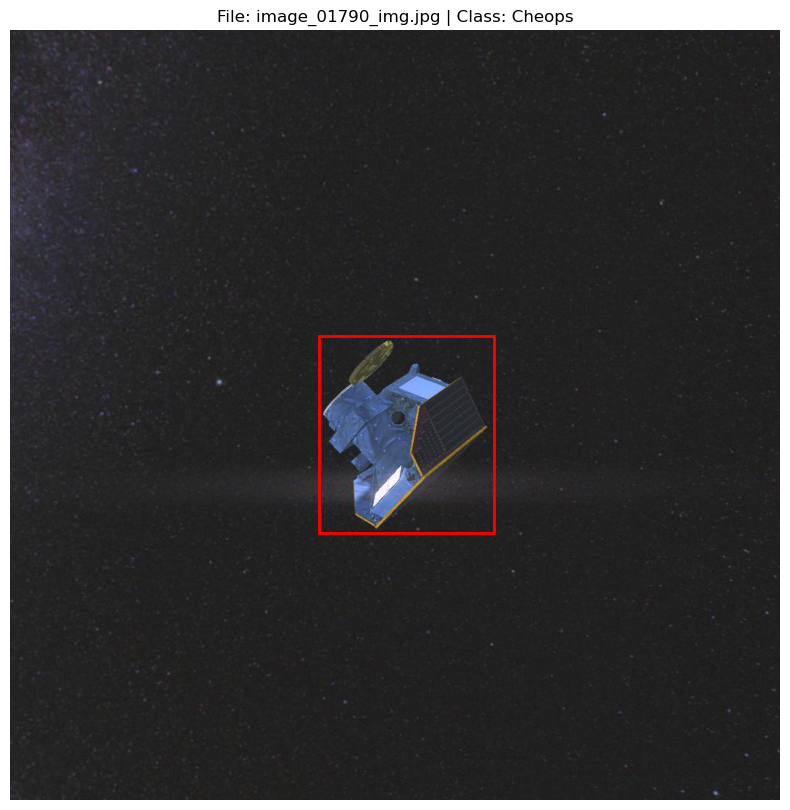

In [6]:
# Pick a random index from the results
random_idx = random.randint(0, len(df) - 1)
visualize_prediction(random_idx)

In [8]:
row = df.iloc[10] # Prendi una riga a caso
crop = get_crop(row, DATA_DIR, split=SPLIT, padding=20)